       Fecha  Ventas
0 2015-01-31  249.84
1 2015-02-28  239.75
2 2015-03-31  289.11
3 2015-04-30  329.54
4 2015-05-31  226.74


/var/folders/p_/t355wf8d61177pp2l7_8j9480000gn/T/ipykernel_49117/3683229443.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start="2015-01-01", periods=120, freq="M")


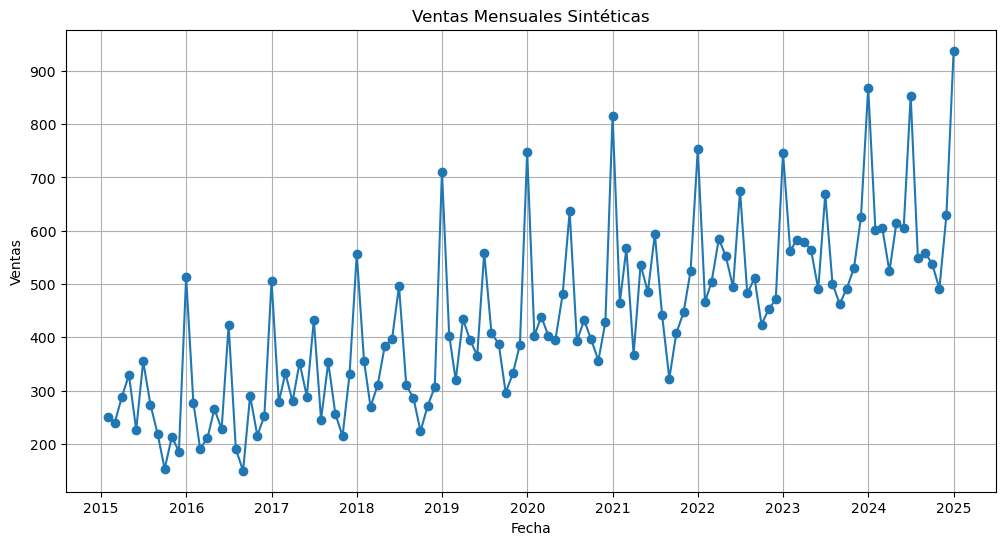

Synthetic sales dataset created and saved as 'ventas_mensuales_sinteticas.csv'


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

# Define the number of months (4 years of monthly data)
months = pd.date_range(start="2015-01-01", periods=120, freq="M")

# Generate a base sales trend (slightly increasing)
trend = np.linspace(100, 500, len(months))

# Add seasonality (e.g., higher sales in Q4, lower in Q1)
seasonality = 100 + 50 * np.sin(2 * np.pi * months.month / 12)

# Add random noise (to make the data more realistic)
noise = np.random.normal(0, 50, len(months))

# Include external events such as promotions (spikes)
promotions = np.zeros(len(months))
promotions[11::12] = 300  # Sales spike every December for holiday season
promotions[5::12] = 150   # Sales spike every June for mid-year sales

# Final sales data is a combination of trend, seasonality, noise, and promotions
sales = trend + seasonality + noise + promotions
sales = np.round(sales, 2)  # Round the sales to 2 decimal places

# Create the DataFrame
data = pd.DataFrame({
    'Fecha': months,
    'Ventas': sales
})

# Show the first few rows of the dataset
print(data.head())

# Plot the synthetic sales data
plt.figure(figsize=(12,6))
plt.plot(data['Fecha'], data['Ventas'], marker='o')
plt.title('Ventas Mensuales Sintéticas')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.show()

# Save the dataset to CSV
data.to_csv('data/ventas_mensuales.csv', index=False)

print("Synthetic sales dataset created and saved as 'ventas_mensuales_sinteticas.csv'")
